# 01  -  Exploratory Data Analysis

**Goal:** Understand the feature matrix before any modelling.
Three questions drive every section:
1. Are per-species distributions what biology predicts?
2. Is the published RESTRICT/FACILITATE pattern (RM ↔ ARG) visible in the new species?
3. Which features vary between species (Q1 signal) vs within species (Q2 signal)?

**Sections:**
1. Per-species summary statistics  -  confirm the numbers make sense
2. Defence system prevalence  -  which systems exist in which species?
3. RESTRICT/FACILITATE check  -  Spearman correlations per species vs published findings
4. Variance decomposition  -  between-species vs within-species feature variance

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load feature matrix ───────────────────────────────────────────────────
fm = pd.read_parquet(PROC / "feature_matrix_3460.parquet")

# ── Column groups ──────────────────────────────────────────────────────────
dp_cols    = [c for c in fm.columns if c.startswith("dp_")]   # defence P/A (360)
dc_cols    = [c for c in fm.columns if c.startswith("dc_")]   # defence counts (360)
ad_cols    = [c for c in fm.columns if c.startswith("ad_")]   # anti-defence P/A (29)
label_cols = ["species", "arg_burden_tertile", "country",
              "year_bin", "complex_member", "sequence_type", "mlst_scheme"]

# Shorthand: features only (no label cols)
feat_cols  = [c for c in fm.columns if c not in label_cols]

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]

SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae complex",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}

print(f"Feature matrix loaded: {fm.shape[0]} genomes × {fm.shape[1]} columns")
print(f"  Feature columns:  {len(feat_cols)}")
print(f"  Label columns:    {len(label_cols)}")
print(f"  Species: {fm['species'].value_counts().to_dict()}")

Feature matrix loaded: 3335 genomes × 791 columns
  Feature columns:  784
  Label columns:    7
  Species: {'paeruginosa': 600, 'saureus': 600, 'abaumannii': 600, 'efaecium': 524, 'ecloaceae': 507, 'kpneumoniae': 504}


## Section 1  —  Per-species summary statistics

In [2]:
# ── Core count variables to summarise ────────────────────────────────────────
SUMMARY_VARS = [v for v in [
    "defence_system_count",
    "arg_count_unique",
    "ime_count_unique",
    "is_count_total",        # excluded if ISEScan incomplete
    "adef_system_count",
    "hmrg_metal_total",
] if v in fm.columns]

# ── Per-species summary table: median [IQR], min–max ─────────────────────────
rows = []
for sp in SPECIES_ORDER:
    sub = fm[fm["species"] == sp]
    row = {"species": SPECIES_LABELS[sp], "n": len(sub)}
    for v in SUMMARY_VARS:
        q1  = sub[v].quantile(0.25)
        med = sub[v].median()
        q3  = sub[v].quantile(0.75)
        mn  = sub[v].min()
        mx  = sub[v].max()
        row[v] = f"{med:.0f} [{q1:.0f}–{q3:.0f}]  ({mn:.0f}–{mx:.0f})"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("species")

print("Per-species summary: median [IQR]  (min–max)")
print("=" * 90)
print(summary_df.to_string())
print()
print("Column key:")
print("  defence_system_count : distinct defence types in genome")
print("  arg_count_unique     : distinct ARG genes (ResFinder)")
print("  ime_count_unique     : distinct ICE/IME elements (ICEberg)")
print("  is_count_total       : total IS elements (ISEScan)")
print("  adef_system_count    : anti-defence system count (DF anti-defence)")
print("  hmrg_metal_total     : metal resistance genes (AMRFinderPlus)")

Per-species summary: median [IQR]  (min–max)
                      n defence_system_count   arg_count_unique    ime_count_unique adef_system_count   hmrg_metal_total
species                                                                                                                 
K. pneumoniae       504   22 [18–25]  (9–39)  16 [9–20]  (2–37)  16 [12–19]  (0–42)   5 [3–6]  (1–10)  20 [6–23]  (1–54)
E. cloacae complex  507   17 [14–20]  (7–32)   6 [2–13]  (0–28)   14 [2–17]  (0–46)    2 [1–3]  (0–7)  20 [7–31]  (1–67)
A. baumannii        600     6 [3–10]  (1–28)  10 [6–12]  (2–23)   11 [9–13]  (0–19)    2 [1–3]  (0–4)    1 [1–1]  (0–12)
E. faecium          524     8 [5–10]  (0–16)   8 [6–10]  (1–17)  12 [10–13]  (1–17)    2 [1–2]  (0–3)     1 [1–1]  (0–8)
P. aeruginosa       600   14 [10–19]  (3–34)   6 [5–10]  (3–29)    2 [1–13]  (0–23)    1 [0–2]  (0–9)    1 [0–6]  (0–26)
S. aureus           600   12 [10–13]  (5–17)    2 [1–6]  (0–14)     4 [0–5]  (0–11)    2 [1–2]  (0–4)    1 [

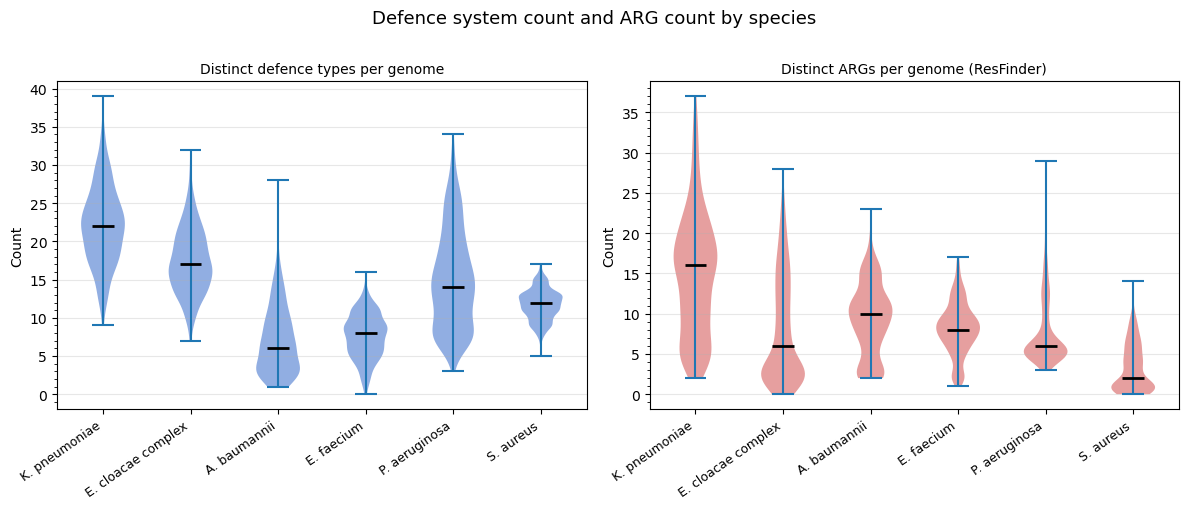

Saved: results/figures/eda/01_defence_arg_violin.png


In [3]:
# ── Violin plots: defence_system_count and arg_count_unique side by side ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Defence system count and ARG count by species", fontsize=13, y=1.01)

sp_labels = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

for ax, var, title, colour in zip(
    axes,
    ["defence_system_count", "arg_count_unique"],
    ["Distinct defence types per genome", "Distinct ARGs per genome (ResFinder)"],
    ["#4878CF", "#D65F5F"],
):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_defence_arg_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/01_defence_arg_violin.png")

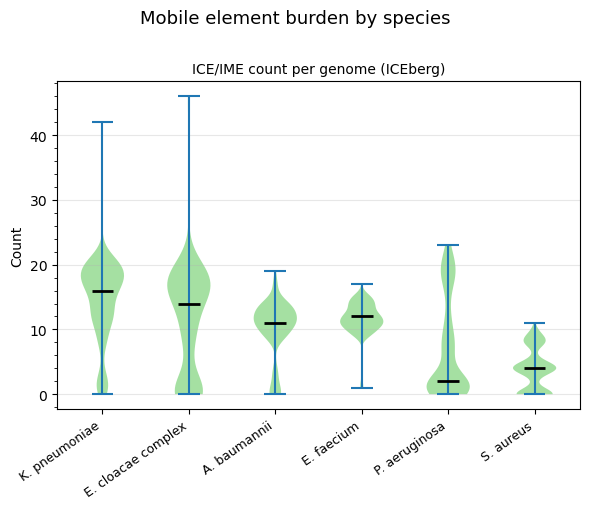

Saved: results/figures/eda/02_ime_is_violin.png


In [4]:
# ── IME and IS counts  -  the MGE burden landscape ─────────────────────────────
_mge = [(v, t, c) for v, t, c in [
    ("ime_count_unique", "ICE/IME count per genome (ICEberg)", "#6ACC65"),
    ("is_count_total",   "IS element count per genome (ISEScan — excluded if incomplete)", "#B47CC7"),
] if v in fm.columns]
_n = len(_mge)
fig, _axes = plt.subplots(1, _n, figsize=(6*_n, 5))
axes = [_axes] if _n == 1 else list(_axes)
fig.suptitle("Mobile element burden by species", fontsize=13, y=1.01)

for ax, (var, title, colour) in zip(axes, _mge):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_ime_is_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/02_ime_is_violin.png")

## Section 2  —  Defence system prevalence

In [5]:
# ── Compute per-species prevalence for each defence system type ───────────────

dp_cols = [c for c in fm.columns if c.startswith("dp_")]

prev = pd.DataFrame(
    {sp: fm[fm["species"] == sp][dp_cols].mean() for sp in SPECIES_ORDER},
    index=dp_cols,
)
prev.index = [c.replace("dp_", "") for c in prev.index]  # strip prefix for legibility
prev.columns = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

print(f"Prevalence matrix shape: {prev.shape}  (defence types × species)")
print()

# ── How many systems are near-universal? (>80% in all 6 species) ─────────────
near_universal = prev[(prev > 0.80).all(axis=1)]
print(f"Near-universal systems (>80% in ALL 6 species): {len(near_universal)}")
if len(near_universal):
    print(near_universal.to_string())
print()

# ── How many are completely absent from AB? (prevalence = 0) ─────────────────
ab_absent = prev[prev["A. baumannii"] == 0]
print(f"Systems absent from ALL A. baumannii genomes: {len(ab_absent)}")
print()

# ── Top 10 most prevalent systems per species ─────────────────────────────────
print("Top 5 most prevalent systems per species:")
for sp_label in [SPECIES_LABELS[s] for s in SPECIES_ORDER]:
    top5 = prev[sp_label].nlargest(5)
    print(f"  {sp_label}:")
    for sys_name, val in top5.items():
        print(f"    {sys_name:<35} {val:.2f}")
    print()

Prevalence matrix shape: (360, 6)  (defence types × species)

Near-universal systems (>80% in ALL 6 species): 0

Systems absent from ALL A. baumannii genomes: 166

Top 5 most prevalent systems per species:
  K. pneumoniae:
    padloc_PDC-S07                      1.00
    padloc_PDC-S04                      0.99
    padloc_PDC-S12                      0.99
    VSPR                                0.99
    AbiE                                0.92

  E. cloacae complex:
    padloc_PDC-S07                      0.99
    VSPR                                0.99
    padloc_PDC-S12                      0.99
    PD-T4-6                             0.94
    RM_Type_I                           0.60

  A. baumannii:
    SspBCDE                             0.47
    padloc_PDC-S15                      0.38
    RM_Type_I                           0.34
    Gao_Qat                             0.30
    RosmerTA                            0.27

  E. faecium:
    AbiE                                0.81
  

Systems with any presence: 360 of 360


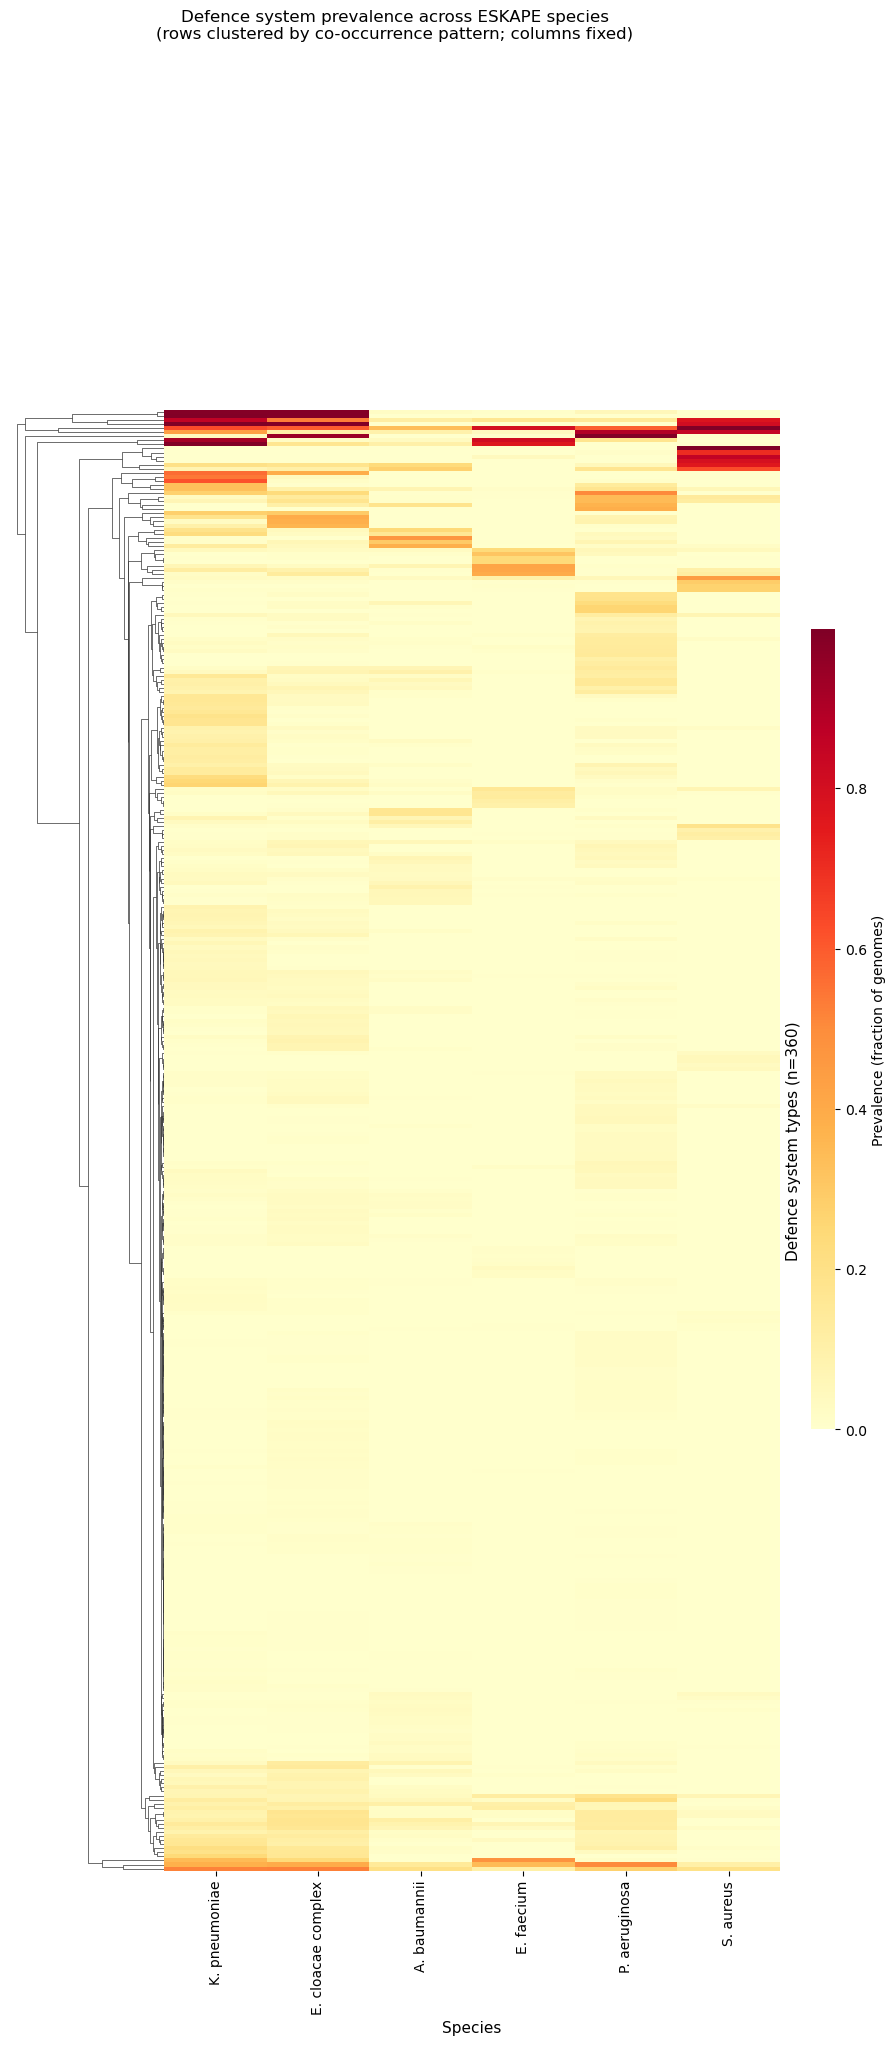

Saved: results/figures/eda/03_defence_prevalence_heatmap.png


In [6]:
# ── Full prevalence heatmap (hierarchically clustered rows) ──────────────────

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Filter: keep only systems present in ≥1 genome (prevalence > 0 in any species)
prev_nonzero = prev[(prev > 0).any(axis=1)]
print(f"Systems with any presence: {len(prev_nonzero)} of {len(prev)}")

g = sns.clustermap(
    prev_nonzero,
    col_cluster=False,         # keep species columns in SPECIES_ORDER
    row_cluster=True,          # cluster defence types by co-occurrence pattern
    cmap="YlOrRd",
    figsize=(8, 20),
    xticklabels=True,
    yticklabels=False,         # 274 labels illegible at this size
    linewidths=0,
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
    cbar_kws={"label": "Prevalence (fraction of genomes)"},
)
g.ax_heatmap.set_xlabel("Species", fontsize=11)
g.ax_heatmap.set_ylabel(f"Defence system types (n={len(prev_nonzero)})", fontsize=11)
g.fig.suptitle(
    "Defence system prevalence across ESKAPE species\n"
    "(rows clustered by co-occurrence pattern; columns fixed)",
    y=1.01, fontsize=12,
)
plt.savefig(FIG_DIR / "03_defence_prevalence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/03_defence_prevalence_heatmap.png")

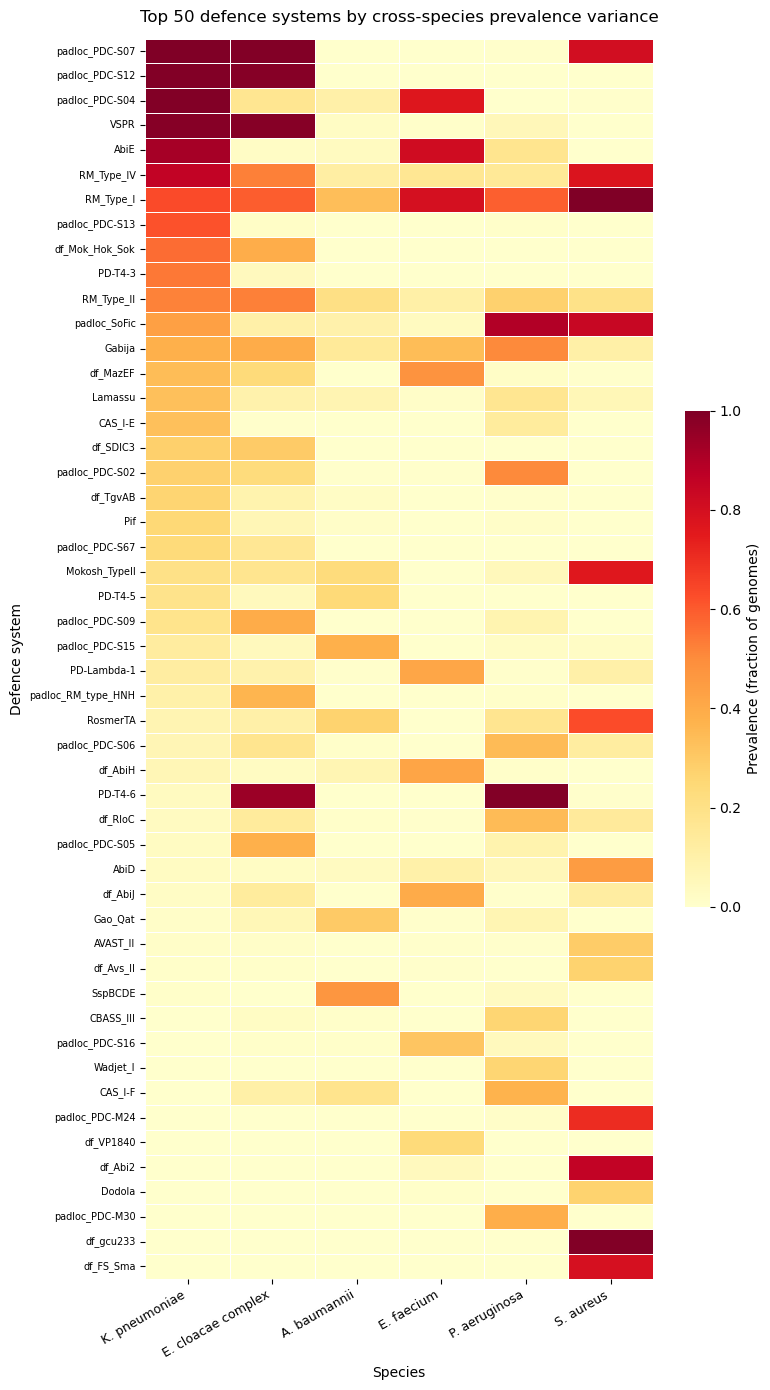

Saved: results/figures/eda/04_defence_prevalence_top50.png


In [7]:
# ── Zoom heatmap: top 50 systems by cross-species variance ────────────────────

row_variance = prev_nonzero.var(axis=1)
top50 = prev_nonzero.loc[row_variance.nlargest(50).index]
top50 = top50.sort_values(by=list(top50.columns), ascending=False)

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    top50,
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.4,
    linecolor="white",
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Prevalence (fraction of genomes)", "shrink": 0.4},
)
ax.set_title(
    "Top 50 defence systems by cross-species prevalence variance",
    fontsize=12, pad=12,
)
ax.set_xlabel("Species", fontsize=10)
ax.set_ylabel("Defence system", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_defence_prevalence_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/04_defence_prevalence_top50.png")

In [8]:
# ── Check prevalence of the published key systems in all 6 species ────────────

KEY_SYSTEMS = [
    "RM_Type_I",
    "RM_Type_II",
    "RM_Type_III",
    "RM_Type_IV",
    "SspBCDE",
    "Gao_Qat",
    "Gabija",
    "Druantia",
    "Lamassu",
    "Thoeris",
    "Zorya",
    "CRISPR_Cas",
]

found_systems = [s for s in KEY_SYSTEMS if s in prev.index]
missing_systems = [s for s in KEY_SYSTEMS if s not in prev.index]

print("Published key systems  -  prevalence across species:")
print("=" * 90)
print(prev.loc[found_systems].to_string(float_format=lambda x: f"{x:.2f}"))
print()
if missing_systems:
    print(f"Not found in feature matrix (may be absent from all genomes): {missing_systems}")

Published key systems  -  prevalence across species:
             K. pneumoniae  E. cloacae complex  A. baumannii  E. faecium  P. aeruginosa  S. aureus
RM_Type_I             0.63                0.60          0.34        0.80           0.59       1.00
RM_Type_II            0.52                0.52          0.20        0.11           0.28       0.20
RM_Type_III           0.11                0.16          0.07        0.03           0.13       0.02
RM_Type_IV            0.86                0.53          0.12        0.17           0.15       0.78
SspBCDE               0.01                0.00          0.47        0.00           0.03       0.00
Gao_Qat               0.01                0.06          0.30        0.01           0.07       0.00
Gabija                0.38                0.40          0.15        0.34           0.51       0.11
Lamassu               0.33                0.09          0.07        0.01           0.17       0.06

Not found in feature matrix (may be absent from all gen

## Section 3  —  RESTRICT/FACILITATE check

In [9]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ── Define which variables to test against ARG ────────────────────────────────
RESTRICT_VARS = ["dc_RM_Type_I", "dc_RM_Type_II", "dc_RM_Type_III", "dc_RM_Type_IV"]
FACILITATE_VARS = ["dp_SspBCDE", "dp_Gao_Qat"]
SUMMARY_VARS_CORR = ["defence_system_count", "adef_system_count",
                     "ime_count_unique", "is_count_total"]
TARGET = "arg_count_unique"

ALL_VARS = RESTRICT_VARS + FACILITATE_VARS + SUMMARY_VARS_CORR

# ── Filter: only include vars that exist in the feature matrix ────────────────
ALL_VARS = [v for v in ALL_VARS if v in fm.columns]

print(f"Testing {len(ALL_VARS)} variables against {TARGET} per species")
print(f"Restrict: {RESTRICT_VARS}")
print(f"Facilitate: {FACILITATE_VARS}")
print()

# ── Per-species Spearman + BH correction ─────────────────────────────────────
results = []
for sp in SPECIES_ORDER:
    sub = fm[fm["species"] == sp].copy()
    rhos, pvals, var_names = [], [], []
    for var in ALL_VARS:
        if var not in sub.columns:
            continue
        # Drop rows where either variable is NaN
        pair = sub[[var, TARGET]].dropna()
        if len(pair) < 10 or pair[var].nunique() < 2:
            # Skip if too few observations or zero variance
            rho, p = np.nan, np.nan
        else:
            rho, p = spearmanr(pair[var], pair[TARGET])
        rhos.append(rho)
        pvals.append(p)
        var_names.append(var)

    # BH correction within this species
    valid = [(i, p) for i, p in enumerate(pvals) if not np.isnan(p)]
    padj = [np.nan] * len(pvals)
    if valid:
        idx_v, pv = zip(*valid)
        _, p_adj, _, _ = multipletests(list(pv), method="fdr_bh")
        for i, pa in zip(idx_v, p_adj):
            padj[i] = pa

    for var, rho, p, pa in zip(var_names, rhos, pvals, padj):
        results.append({
            "species": SPECIES_LABELS[sp],
            "variable": var,
            "rho": rho,
            "p_raw": p,
            "p_adj_BH": pa,
            "sig": "*" if pa < 0.05 else ("†" if pa < 0.10 else ""),
        })

corr_df = pd.DataFrame(results)

# ── Print per-species results for RM types ────────────────────────────────────
print("Spearman ρ: RM systems vs ARG count (per species, BH-corrected)")
print("* = FDR < 0.05    † = FDR < 0.10")
print("=" * 85)
for sp_label in [SPECIES_LABELS[s] for s in SPECIES_ORDER]:
    sp_data = corr_df[
        (corr_df["species"] == sp_label) &
        (corr_df["variable"].isin(RESTRICT_VARS + FACILITATE_VARS))
    ]
    print(f"\n{sp_label}:")
    for _, row in sp_data.iterrows():
        rho_str = f"{row['rho']:+.3f}" if not np.isnan(row["rho"]) else "  n/a "
        p_str   = f"{row['p_adj_BH']:.3f}" if not np.isnan(row["p_adj_BH"]) else "  n/a"
        print(f"  {row['variable']:<25} ρ={rho_str}  p_adj={p_str}  {row['sig']}")

Testing 9 variables against arg_count_unique per species
Restrict: ['dc_RM_Type_I', 'dc_RM_Type_II', 'dc_RM_Type_III', 'dc_RM_Type_IV']
Facilitate: ['dp_SspBCDE', 'dp_Gao_Qat']

Spearman ρ: RM systems vs ARG count (per species, BH-corrected)
* = FDR < 0.05    † = FDR < 0.10

K. pneumoniae:
  dc_RM_Type_I              ρ=+0.326  p_adj=0.000  *
  dc_RM_Type_II             ρ=+0.377  p_adj=0.000  *
  dc_RM_Type_III            ρ=-0.020  p_adj=0.734  
  dc_RM_Type_IV             ρ=-0.033  p_adj=0.584  
  dp_SspBCDE                ρ=-0.101  p_adj=0.034  *
  dp_Gao_Qat                ρ=-0.005  p_adj=0.913  

E. cloacae complex:
  dc_RM_Type_I              ρ=-0.038  p_adj=0.389  
  dc_RM_Type_II             ρ=+0.312  p_adj=0.000  *
  dc_RM_Type_III            ρ=-0.050  p_adj=0.353  
  dc_RM_Type_IV             ρ=+0.104  p_adj=0.030  *
  dp_SspBCDE                ρ=  n/a   p_adj=  n/a  
  dp_Gao_Qat                ρ=-0.039  p_adj=0.389  

A. baumannii:
  dc_RM_Type_I              ρ=-0.283  p_adj=

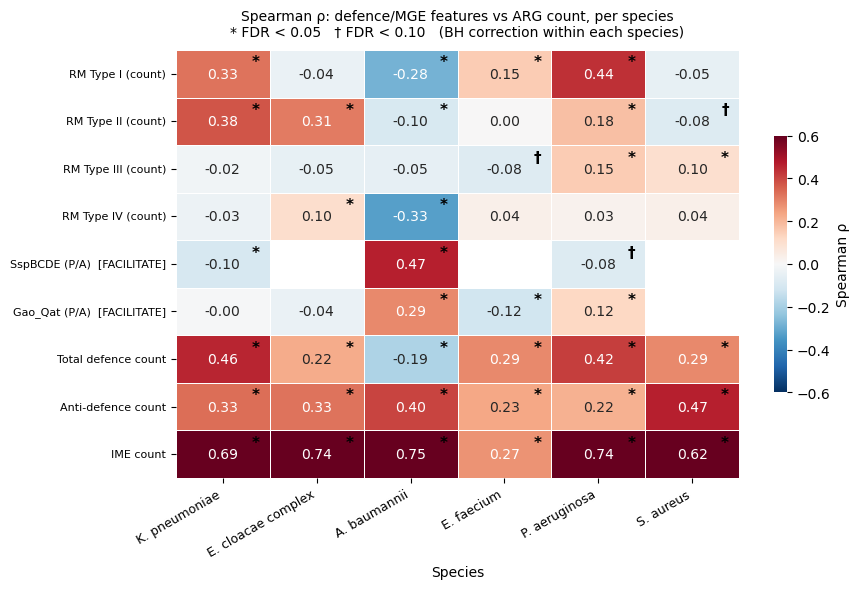

Saved: results/figures/eda/05_restrict_facilitate_heatmap.png


In [10]:
# ── Correlation heatmap: all tested variables × all species ──────────────────
pivot_rho = corr_df.pivot(index="variable", columns="species", values="rho")
pivot_sig = corr_df.pivot(index="variable", columns="species", values="sig")

# Reorder columns to SPECIES_ORDER
sp_labels_ordered = [SPECIES_LABELS[s] for s in SPECIES_ORDER]
pivot_rho = pivot_rho[sp_labels_ordered]
pivot_sig = pivot_sig[sp_labels_ordered]

# Row order: RM restrict → facilitate → summary
var_order = [v for v in RESTRICT_VARS + FACILITATE_VARS + SUMMARY_VARS_CORR
             if v in pivot_rho.index]
pivot_rho = pivot_rho.loc[var_order]
pivot_sig = pivot_sig.loc[var_order]

# Clean up row labels
row_labels = {
    "dc_RM_Type_I":        "RM Type I (count)",
    "dc_RM_Type_II":       "RM Type II (count)",
    "dc_RM_Type_III":      "RM Type III (count)",
    "dc_RM_Type_IV":       "RM Type IV (count)",
    "dp_SspBCDE":          "SspBCDE (P/A)  [FACILITATE]",
    "dp_Gao_Qat":          "Gao_Qat (P/A)  [FACILITATE]",
    "defence_system_count":"Total defence count",
    "adef_system_count":   "Anti-defence count",
    "ime_count_unique":    "IME count",
    "is_count_total":      "IS element count",
}
pivot_rho.index = [row_labels.get(v, v) for v in pivot_rho.index]
pivot_sig.index = pivot_rho.index

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot_rho,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-0.6, vmax=0.6,
    annot=pivot_rho.round(2),
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Spearman ρ", "shrink": 0.6},
)

# Overlay significance stars
for row_i, row_name in enumerate(pivot_rho.index):
    for col_i, col_name in enumerate(pivot_rho.columns):
        sig = pivot_sig.loc[row_name, col_name]
        if sig:
            ax.text(col_i + 0.85, row_i + 0.25, sig,
                    ha="center", va="center", fontsize=11, color="black", weight="bold")

ax.set_title(
    "Spearman ρ: defence/MGE features vs ARG count, per species\n"
    "* FDR < 0.05   † FDR < 0.10   (BH correction within each species)",
    fontsize=10, pad=10,
)
ax.set_xlabel("Species", fontsize=10)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_restrict_facilitate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/05_restrict_facilitate_heatmap.png")

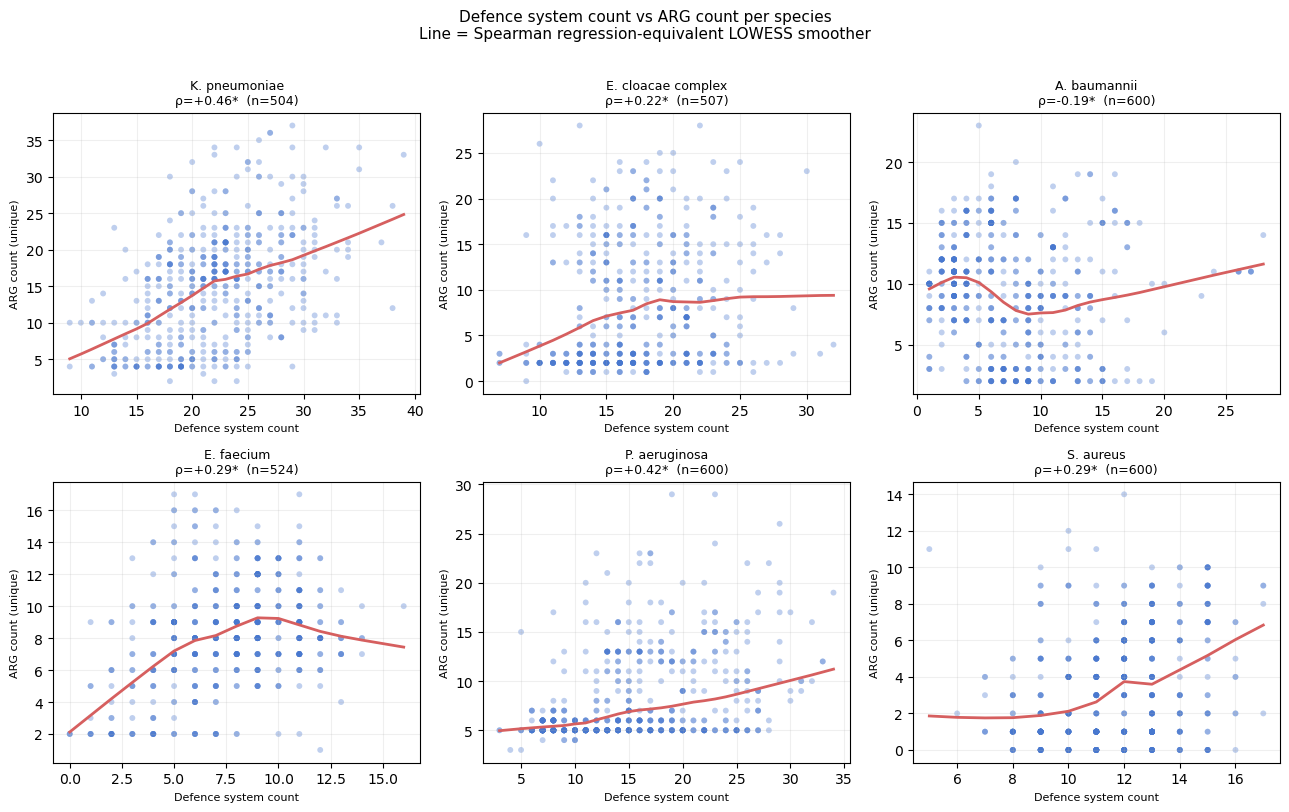

Saved: results/figures/eda/06_defence_arg_scatter_facet.png


In [11]:
# ── Scatter: defence_system_count vs arg_count_unique, faceted by species ─────

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=False)
axes = axes.flatten()
fig.suptitle(
    "Defence system count vs ARG count per species\n"
    "Line = Spearman regression-equivalent LOWESS smoother",
    fontsize=11, y=1.01
)

from scipy.stats import spearmanr
import statsmodels.api as sm

for ax, sp in zip(axes, SPECIES_ORDER):
    sub = fm[fm["species"] == sp]
    x = sub["defence_system_count"].values
    y = sub["arg_count_unique"].values

    rho, p = spearmanr(x, y)
    sig_label = "*" if p < 0.05 else ""

    ax.scatter(x, y, alpha=0.35, s=18, color="#4878CF", edgecolors="none")

    # LOWESS smoother
    lowess = sm.nonparametric.lowess(y, x, frac=0.5)
    ax.plot(lowess[:, 0], lowess[:, 1], color="#D65F5F", lw=2)

    ax.set_title(
        f"{SPECIES_LABELS[sp]}\nρ={rho:+.2f}{sig_label}  (n={len(sub)})",
        fontsize=9
    )
    ax.set_xlabel("Defence system count", fontsize=8)
    ax.set_ylabel("ARG count (unique)", fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_defence_arg_scatter_facet.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/06_defence_arg_scatter_facet.png")

## Section 4  —  Variance decomposition: between-species vs within-species

In [12]:
from scipy import stats as scipy_stats

feat_cols = [c for c in fm.columns
             if c not in ["species", "arg_burden_tertile", "country", "year_bin",
                          "complex_member", "sequence_type", "mlst_scheme"]
             and pd.api.types.is_numeric_dtype(fm[c])]

print(f"Computing η² for {len(feat_cols)} feature columns ...")

eta2_vals = {}
for col in feat_cols:
    groups = [fm[fm["species"] == sp][col].dropna().values for sp in SPECIES_ORDER]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        eta2_vals[col] = np.nan
        continue
    # One-way ANOVA
    grand_mean = fm[col].mean()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2 for g in groups
    )
    ss_total = sum(((v - grand_mean) ** 2) for g in groups for v in g)
    eta2_vals[col] = ss_between / ss_total if ss_total > 0 else np.nan

eta2 = pd.Series(eta2_vals, name="eta2").dropna().sort_values(ascending=False)

print(f"η² computed for {len(eta2)} features")
print()
print("Distribution of η² across all features:")
for cut, label in [(0.8, ">0.80 (strong species marker)"),
                   (0.5, "0.50–0.80 (moderate)"),
                   (0.20, "0.20–0.50 (mixed)"),
                   (0.0,  "<0.20 (mainly within-species)")]:
    n = (eta2 > cut).sum() if cut > 0 else len(eta2)
    if cut == 0.8:
        n_band = (eta2 > 0.8).sum()
    elif cut == 0.5:
        n_band = ((eta2 > 0.5) & (eta2 <= 0.8)).sum()
    elif cut == 0.20:
        n_band = ((eta2 > 0.20) & (eta2 <= 0.5)).sum()
    else:
        n_band = (eta2 <= 0.20).sum()
    print(f"  {label}: {n_band} features  ({100*n_band/len(eta2):.1f}%)")

print()
print("Top 20 features by η² (strongest species markers):")
print(eta2.head(20).to_string())
print()
print("Bottom 20 features by η² (most within-species variation):")
print(eta2.tail(20).to_string())

Computing η² for 783 feature columns ...


η² computed for 782 features

Distribution of η² across all features:
  >0.80 (strong species marker): 12 features  (1.5%)
  0.50–0.80 (moderate): 23 features  (2.9%)
  0.20–0.50 (mixed): 63 features  (8.1%)
  <0.20 (mainly within-species): 684 features  (87.5%)

Top 20 features by η² (strongest species markers):
dp_df_gcu233                0.993910
dp_padloc_PDC-S12           0.987287
ad_adf_apyc1                0.963889
dc_padloc_PDC-S07           0.952865
ad_adf_NARP1                0.935719
dp_PD-T4-6                  0.923271
dp_VSPR                     0.910545
dc_VSPR                     0.907224
dc_padloc_PDC-S12           0.893645
dp_padloc_PDC-S07           0.877660
dc_PD-T4-6                  0.871124
dc_df_gcu233                0.863658
dp_df_Abi2                  0.789377
dp_df_FS_Sma                0.758925
ad_adf_Aca_alone            0.755528
dc_df_Abi2                  0.753438
ad_adf_ardb_klca_acric11    0.709599
dp_padloc_PDC-S04           0.683551
dp_AbiE            

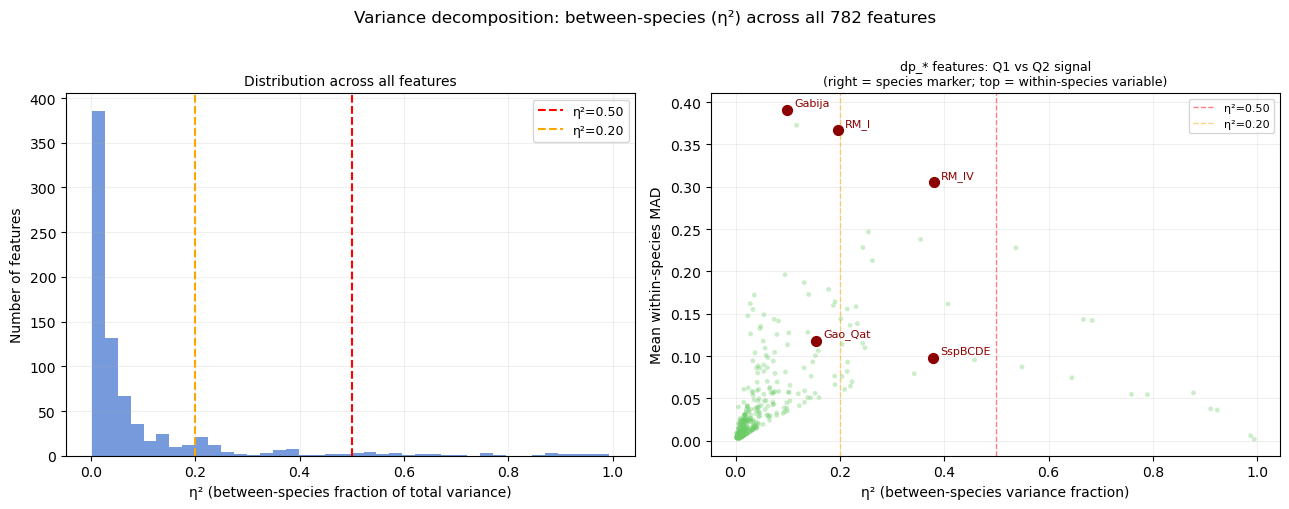

Saved: results/figures/eda/07_variance_decomposition.png


In [13]:
# ── Distribution of η² + highlight key features ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Variance decomposition: between-species (η²) across all {len(eta2)} features",
             fontsize=12, y=1.01)

# Left: histogram of all η² values
ax = axes[0]
ax.hist(eta2.values, bins=40, color="#4878CF", alpha=0.75, edgecolor="none")
ax.axvline(0.5, color="red", lw=1.5, ls="--", label="η²=0.50")
ax.axvline(0.2, color="orange", lw=1.5, ls="--", label="η²=0.20")
ax.set_xlabel("η² (between-species fraction of total variance)", fontsize=10)
ax.set_ylabel("Number of features", fontsize=10)
ax.set_title("Distribution across all features", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Right: scatter  -  Q1 vs Q2 candidates among the dp_* and dc_* columns
ax2 = axes[1]

dp_eta2 = eta2[[c for c in eta2.index if c.startswith("dp_")]]
within_mad = {}
for col in dp_eta2.index:
    mads = []
    for sp in SPECIES_ORDER:
        s = fm[fm["species"] == sp][col]
        mads.append((s - s.mean()).abs().mean())
    within_mad[col] = np.mean(mads)

within_mad_s = pd.Series(within_mad)
ax2.scatter(dp_eta2.values, within_mad_s[dp_eta2.index].values,
            alpha=0.35, s=12, color="#6ACC65", edgecolors="none")

# Annotate the key published systems
key_systems = {
    "dp_SspBCDE": "SspBCDE",
    "dp_Gao_Qat": "Gao_Qat",
    "dp_RM_Type_I": "RM_I",
    "dp_RM_Type_IV": "RM_IV",
    "dp_Gabija": "Gabija",
}
for col, label in key_systems.items():
    if col in dp_eta2.index:
        ax2.annotate(
            label,
            xy=(dp_eta2[col], within_mad_s[col]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=8, color="darkred",
        )
        ax2.scatter([dp_eta2[col]], [within_mad_s[col]],
                    s=50, color="darkred", zorder=5)

ax2.axvline(0.5, color="red", lw=1, ls="--", alpha=0.5, label="η²=0.50")
ax2.axvline(0.2, color="orange", lw=1, ls="--", alpha=0.5, label="η²=0.20")
ax2.set_xlabel("η² (between-species variance fraction)", fontsize=10)
ax2.set_ylabel("Mean within-species MAD", fontsize=10)
ax2.set_title("dp_* features: Q1 vs Q2 signal\n(right = species marker; top = within-species variable)",
              fontsize=9)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_variance_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/07_variance_decomposition.png")

In [14]:
# ── Where do the published key systems sit in η² space? ─────────────────────
key_cols = {
    "dp_RM_Type_I":   "RM_Type_I (P/A)",
    "dp_RM_Type_II":  "RM_Type_II (P/A)",
    "dp_RM_Type_III": "RM_Type_III (P/A)",
    "dp_RM_Type_IV":  "RM_Type_IV (P/A)",
    "dp_SspBCDE":     "SspBCDE (P/A)",
    "dp_Gao_Qat":     "Gao_Qat (P/A)",
    "dp_Gabija":      "Gabija (P/A)",
    "dc_RM_Type_I":   "RM_Type_I (count)",
    "dc_RM_Type_IV":  "RM_Type_IV (count)",
    "dc_SspBCDE":     "SspBCDE (count)" if "dc_SspBCDE" in eta2.index else None,
    "defence_system_count": "Total defence count",
    "arg_count_unique":     "ARG count (unique)  [TARGET]",
    "ime_count_unique":     "IME count (unique)",
    "is_count_total":       "IS count (total)",
}
key_cols = {k: v for k, v in key_cols.items() if v is not None and k in eta2.index}

print("η² for published key systems and summary features:")
print("=" * 65)
print(f"{'Feature':<35} {'η²':>8}   Interpretation")
print("-" * 65)
for col, label in key_cols.items():
    e = eta2[col]
    if e >= 0.8:
        interp = "strong species marker (Q1)"
    elif e >= 0.5:
        interp = "moderate species signal"
    elif e >= 0.2:
        interp = "mixed  -  both Q1 and Q2"
    else:
        interp = "mainly within-species (Q2)"
    print(f"{label:<35} {e:>8.3f}   {interp}")

η² for published key systems and summary features:
Feature                                   η²   Interpretation
-----------------------------------------------------------------
RM_Type_I (P/A)                        0.195   mainly within-species (Q2)
RM_Type_II (P/A)                       0.117   mainly within-species (Q2)
RM_Type_III (P/A)                      0.033   mainly within-species (Q2)
RM_Type_IV (P/A)                       0.381   mixed  -  both Q1 and Q2
SspBCDE (P/A)                          0.378   mixed  -  both Q1 and Q2
Gao_Qat (P/A)                          0.155   mainly within-species (Q2)
Gabija (P/A)                           0.099   mainly within-species (Q2)
RM_Type_I (count)                      0.207   mixed  -  both Q1 and Q2
RM_Type_IV (count)                     0.325   mixed  -  both Q1 and Q2
SspBCDE (count)                        0.374   mixed  -  both Q1 and Q2
Total defence count                    0.566   moderate species signal
ARG count (unique)  